# Week 4 Experiment: Fractal Dimension via Persistent Homology
## Log-Log Plot Analysis of Neural Representations Near Phase Transition

**Research Project:** Pattern Interpretability in Neural Networks — Log-Normal Weight Distributions

**Method Reference:** Adams et al. (2018), *A Fractal Dimension for Measures via Persistent Homology*, arXiv:1808.01079

### Core Idea
For a point cloud of `n` points sampled from a measure μ, the **total sum of H_i persistent homology interval lengths** scales as:
$$L_i(n) \sim C \cdot n^{1 - 1/\mathrm{dim}_{PH}^i(\mu)}$$
So a **log-log plot** of `L_i(n)` vs `n` gives a straight line whose slope `s = 1 - 1/dim_PH` → `dim_PH = 1/(1-s)`.

### What We Measure
1. **Experiment A:** Fractal dimension of **PCA-reduced logit representations at different network depths** (across the depth sweep near the phase boundary). One D×W config per point.
2. **Experiment B:** Fractal dimension of **middle-layer activations for several input images** inside a single network — tracked layer by layer to see where fractality emerges/collapses near the phase transition.

**Hypothesis (from physics):** At the phase transition boundary, the representation should exhibit signatures of fractality — the log-log plot should show a clean power-law scaling, and the estimated `dim_PH` should show anomalous behavior (divergence, non-integer value, or inflection) near the critical depth.

In [78]:
# ── 0. INSTALL DEPENDENCIES ──────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'ripser', 'persim', '--quiet'], check=True)
print('Dependencies ready.')

Dependencies ready.


In [79]:
# ── 1. IMPORTS ────────────────────────────────────────────────────────────────
import os, time, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import ripser

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


In [80]:
# ── 2. CONFIGURATION ──────────────────────────────────────────────────────────

# Architecture sweep (from mentor spec)
DEPTHS_TO_TEST = [22, 23, 24, 26]   # spans functional → near-collapse boundary
WIDTHS_TO_TEST = [64, 128, 256, 512]

# Training config
EPOCHS = 10
BATCH  = 256
LR     = 1e-3

# PH fractal dimension config
# n_values: different subsample sizes for the log-log plot
N_VALUES      = [50, 100, 200, 400, 600, 800, 1000]   # n points sampled each time
N_REPEATS     = 5     # repeat each n for averaging (reduces variance)
PCA_DIM       = 20    # reduce to this before PH (keeps computation fast)
PH_MAXDIM     = 1     # compute H0 and H1
PH_THRESH     = 5.0   # Vietoris-Rips threshold

# Experiment B: which layers to analyse inside each network
# We'll take early / middle / late layer indices
LAYER_FRACTIONS = [0.1, 0.25, 0.5, 0.75, 0.9]   # fraction of total depth

# N images for Experiment B (per-layer, per-class)
N_IMAGES_PER_CLASS = 30   # 10 classes × 30 = 300 images total

print('Configuration set.')

Configuration set.


In [81]:
# ── 3. MLP ARCHITECTURE (exact spec from mentor) ──────────────────────────────

class DynamicMLP(nn.Module):
    def __init__(self, depth, width, input_dim=784, num_classes=10):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(input_dim, width), nn.ReLU()]
        for _ in range(depth - 2):
            layers.append(nn.Linear(width, width))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(width, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

    def get_layer_activations(self, x, layer_indices):
        """Extract activations at specified layer indices (0-indexed over all modules)."""
        activations = {}
        h = x
        for idx, module in enumerate(self.net):
            h = module(h)
            if idx in layer_indices:
                activations[idx] = h.detach().cpu()
        return activations

# Quick sanity check
m = DynamicMLP(depth=5, width=64).to(DEVICE)
x = torch.randn(4, 1, 28, 28).to(DEVICE)
print(f'Output shape: {m(x).shape}  — architecture OK')
print(f'Number of modules in net (D=5,W=64): {len(list(m.net))}')

Output shape: torch.Size([4, 10])  — architecture OK
Number of modules in net (D=5,W=64): 10


In [82]:
# ── 4. DATA LOADING ───────────────────────────────────────────────────────────

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

# Fixed balanced subset for extraction (N_IMAGES_PER_CLASS per class)
# Used consistently across all experiments
def get_balanced_subset(dataset, n_per_class=30):
    indices = []
    counts  = {c: 0 for c in range(10)}
    for i, (_, label) in enumerate(dataset):
        if counts[label] < n_per_class:
            indices.append(i)
            counts[label] += 1
        if all(v >= n_per_class for v in counts.values()):
            break
    return indices

subset_indices = get_balanced_subset(test_dataset, N_IMAGES_PER_CLASS)
subset_loader  = DataLoader(
    Subset(test_dataset, subset_indices),
    batch_size=BATCH, shuffle=False
)
subset_labels = [test_dataset[i][1] for i in subset_indices]

print(f'Train: {len(train_dataset)} | Test: {len(test_dataset)}')
print(f'Extraction subset: {len(subset_indices)} images ({N_IMAGES_PER_CLASS} per class)')

Train: 60000 | Test: 10000
Extraction subset: 300 images (30 per class)


In [83]:
# ── 5. TRAINING FUNCTION ──────────────────────────────────────────────────────

def train_model(depth, width, verbose=True):
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    model = DynamicMLP(depth=depth, width=width).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'test_acc': []}

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Test accuracy
        model.eval()
        correct = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                correct += (model(xb).argmax(1) == yb).sum().item()
        acc = 100.0 * correct / len(test_dataset)
        history['train_loss'].append(total_loss / len(train_loader))
        history['test_acc'].append(acc)
        if verbose:
            print(f'  Epoch {epoch:02d}/{EPOCHS}  loss={total_loss/len(train_loader):.4f}  test_acc={acc:.2f}%')

    final_acc = history['test_acc'][-1]
    best_acc  = max(history['test_acc'])
    status = 'FUNCTIONAL' if final_acc > 70 else ('NEAR-COLLAPSE' if final_acc >= 20 else 'COLLAPSED')
    if verbose:
        print(f'\n  ✓ D{depth} W{width}: final={final_acc:.2f}%  best={best_acc:.2f}%  [{status}]')
    return model, history, final_acc, best_acc, status

print('Training function defined.')

Training function defined.


In [84]:
# ── 6. FRACTAL DIMENSION UTILITIES (Adams et al. 1808.01079) ──────────────────

def compute_total_PH_length(points, maxdim=1, thresh=5.0):
    """
    Compute total sum of H0 and H1 persistent homology interval lengths
    for a point cloud. Returns dict: {0: L0, 1: L1}.
    Points: np.array shape (n, d)
    """
    # Ripser expects float32 distance matrix or point cloud
    pts = points.astype(np.float32)
    result = ripser.ripser(pts, maxdim=maxdim, thresh=thresh)['dgms']
    lengths = {}
    for dim, dgm in enumerate(result):
        if len(dgm) == 0:
            lengths[dim] = 0.0
            continue
        # Remove infinite bars (H0 always has one infinite bar)
        finite_mask = np.isfinite(dgm[:, 1])
        finite_bars = dgm[finite_mask]
        if len(finite_bars) == 0:
            lengths[dim] = 0.0
        else:
            lengths[dim] = float(np.sum(finite_bars[:, 1] - finite_bars[:, 0]))
    return lengths


def compute_loglog_fractal_dim(point_cloud, n_values=N_VALUES, n_repeats=N_REPEATS,
                                pca_dim=PCA_DIM, maxdim=PH_MAXDIM, thresh=PH_THRESH):
    """
    Adams et al. log-log plot method for estimating dim_PH.

    For each n in n_values, sample n points from point_cloud n_repeats times,
    compute total PH length L(n), average over repeats.
    Fit log(L(n)) ~ slope * log(n) + intercept.
    dim_PH = 1 / (1 - slope)  [from L(n) ~ n^(1 - 1/d)]

    Returns:
        results: dict with keys:
            'n_values', 'L0_mean', 'L0_std', 'L1_mean', 'L1_std',
            'slope_H0', 'slope_H1', 'r2_H0', 'r2_H1',
            'dim_PH_H0', 'dim_PH_H1'
    """
    # Reduce dimensionality first for speed and numerical stability
    actual_pca_dim = min(pca_dim, point_cloud.shape[1], point_cloud.shape[0] - 1)
    scaler = StandardScaler()
    pts_scaled = scaler.fit_transform(point_cloud)
    if actual_pca_dim < point_cloud.shape[1]:
        pca = PCA(n_components=actual_pca_dim, random_state=42)
        pts_reduced = pca.fit_transform(pts_scaled)
    else:
        pts_reduced = pts_scaled

    L0_runs = []  # shape: (len(n_values), n_repeats)
    L1_runs = []

    for n in n_values:
        if n > len(pts_reduced):
            n = len(pts_reduced)  # cap at available points
        l0s, l1s = [], []
        for _ in range(n_repeats):
            idx = np.random.choice(len(pts_reduced), size=n, replace=False)
            sample = pts_reduced[idx]
            lengths = compute_total_PH_length(sample, maxdim=maxdim, thresh=thresh)
            l0s.append(lengths.get(0, 0.0))
            l1s.append(lengths.get(1, 0.0))
        L0_runs.append(l0s)
        L1_runs.append(l1s)

    L0_mean = np.array([np.mean(r) for r in L0_runs])
    L0_std  = np.array([np.std(r)  for r in L0_runs])
    L1_mean = np.array([np.mean(r) for r in L1_runs])
    L1_std  = np.array([np.std(r)  for r in L1_runs])


    # --- FIXED FILTERING BLOCK ---
    ns_raw = np.array([min(n, len(pts_reduced)) for n in n_values], dtype=float)
    ns, unique_idx = np.unique(ns_raw, return_index=True)
    
    # We must filter EVERY array returned by the PH computation
    L0_mean = L0_mean[unique_idx]
    L0_std  = L0_std[unique_idx]  # Added this
    L1_mean = L1_mean[unique_idx]
    L1_std  = L1_std[unique_idx]  # Added this
    # -----------------------------
    

    # Log-log linear fit
    def fit_loglog(L_mean, current_ns):
        valid = L_mean > 0
        # If the model is collapsed, L_mean is often 0. 
        # To avoid nulls, we can return 0.0 instead of np.nan
        if valid.sum() < 3:
            return 0.0, 0.0, 0.0 # Return 0 for slope, R2, and intercept
            
        log_n = np.log(current_ns[valid])
        log_L = np.log(L_mean[valid])

        if np.all(log_n == log_n[0]):
            return 0.0, 0.0, 0.0
            
        slope, intercept, r, p, se = stats.linregress(log_n, log_L)
        return slope, r**2, intercept

    s0, r2_0, _ = fit_loglog(L0_mean, ns)
    s1, r2_1, _ = fit_loglog(L1_mean, ns)

    # dim_PH = 1 / (1 - slope)  [from L ~ n^(1-1/d)]
    dim_H0 = 1.0 / (1.0 - s0) if (not np.isnan(s0) and abs(1 - s0) > 1e-6) else np.nan
    dim_H1 = 1.0 / (1.0 - s1) if (not np.isnan(s1) and abs(1 - s1) > 1e-6) else np.nan

    return {
        'n_values' : ns.tolist(),
        'L0_mean'  : L0_mean.tolist(),
        'L0_std'   : L0_std.tolist(),
        'L1_mean'  : L1_mean.tolist(),
        'L1_std'   : L1_std.tolist(),
        'slope_H0' : float(s0),
        'slope_H1' : float(s1),
        'r2_H0'    : float(r2_0),
        'r2_H1'    : float(r2_1),
        'dim_PH_H0': float(dim_H0),
        'dim_PH_H1': float(dim_H1),
    }

print('Fractal dimension utilities defined.')

Fractal dimension utilities defined.


In [85]:
# ── 7. LOGIT EXTRACTION UTILITY ───────────────────────────────────────────────

@torch.no_grad()
def extract_logits(model, loader):
    """Extract final-layer logits (pre-softmax) for all images in loader."""
    model.eval()
    all_logits = []
    for xb, _ in loader:
        xb = xb.to(DEVICE)
        logits = model(xb).cpu().numpy()
        all_logits.append(logits)
    return np.vstack(all_logits)  # shape (N, 10)


@torch.no_grad()
def extract_layer_activations(model, loader, layer_idx):
    """
    Extract activations from a specific layer index in model.net.
    layer_idx: index into model.net Sequential modules.
    Returns np.array shape (N, width).
    """
    model.eval()
    all_acts = []
    for xb, _ in loader:
        xb = xb.to(DEVICE)
        h = xb
        for i, module in enumerate(model.net):
            h = module(h)
            if i == layer_idx:
                all_acts.append(h.cpu().numpy())
                break
    return np.vstack(all_acts)


def get_linear_layer_indices(model):
    """Return indices of all Linear layers in model.net (these are the 'layers' in the network)."""
    linear_indices = []
    for i, m in enumerate(model.net):
        if isinstance(m, nn.Linear):
            linear_indices.append(i)
    return linear_indices

print('Extraction utilities defined.')

Extraction utilities defined.


In [86]:
# ── 8. EXPERIMENT A: FRACTAL DIM OF LOGIT REPRESENTATIONS ACROSS DEPTH SWEEP ─
# For each (depth, width) configuration:
#   1. Train the network
#   2. Extract logits on the balanced subset (N×10 dim space)
#   3. Run the Adams et al. log-log PH fractal dimension estimation
#   4. Record: dim_PH_H0, dim_PH_H1, slope, R^2, accuracy, status

print('='*70)
print('EXPERIMENT A: Fractal Dimension of Logit Representations')
print('='*70)

expA_results  = []  # list of dicts
trained_models = {}  # cache models for Experiment B

for depth in DEPTHS_TO_TEST:
    for width in WIDTHS_TO_TEST:
        print(f'\n── Training D{depth} W{width} ──')
        t0 = time.time()
        model, history, final_acc, best_acc, status = train_model(depth, width, verbose=False)
        print(f'  Trained in {time.time()-t0:.1f}s | final={final_acc:.2f}% best={best_acc:.2f}% [{status}]')

        # Cache model
        trained_models[(depth, width)] = model

        # Extract logits (N × 10)
        logits = extract_logits(model, subset_loader)
        print(f'  Logits shape: {logits.shape}')

        # Compute PH fractal dimension via log-log plot
        print(f'  Computing PH fractal dimension (this takes ~1 min)...')
        t1 = time.time()
        ph_result = compute_loglog_fractal_dim(logits)
        print(f'  PH done in {time.time()-t1:.1f}s')
        print(f'  dim_PH_H0={ph_result["dim_PH_H0"]:.3f} (R²={ph_result["r2_H0"]:.3f})  '
              f'dim_PH_H1={ph_result["dim_PH_H1"]:.3f} (R²={ph_result["r2_H1"]:.3f})')

        expA_results.append({
            'depth'      : depth,
            'width'      : width,
            'final_acc'  : final_acc,
            'best_acc'   : best_acc,
            'status'     : status,
            'ph_data'    : ph_result,
        })

print('\nExperiment A complete.')

EXPERIMENT A: Fractal Dimension of Logit Representations

── Training D22 W64 ──
  Trained in 41.1s | final=84.43% best=90.61% [FUNCTIONAL]
  Logits shape: (300, 10)
  Computing PH fractal dimension (this takes ~1 min)...
  PH done in 1.1s
  dim_PH_H0=1.262 (R²=0.823)  dim_PH_H1=1.196 (R²=0.999)

── Training D22 W128 ──
  Trained in 41.5s | final=74.68% best=84.50% [FUNCTIONAL]
  Logits shape: (300, 10)
  Computing PH fractal dimension (this takes ~1 min)...
  PH done in 0.4s
  dim_PH_H0=1.343 (R²=0.956)  dim_PH_H1=1.000 (R²=0.000)

── Training D22 W256 ──
  Trained in 51.5s | final=11.35% best=11.35% [COLLAPSED]
  Logits shape: (300, 10)
  Computing PH fractal dimension (this takes ~1 min)...
  PH done in 0.3s
  dim_PH_H0=1.000 (R²=0.000)  dim_PH_H1=1.000 (R²=0.000)

── Training D22 W512 ──
  Trained in 70.7s | final=11.35% best=11.35% [COLLAPSED]
  Logits shape: (300, 10)
  Computing PH fractal dimension (this takes ~1 min)...
  PH done in 0.3s
  dim_PH_H0=1.000 (R²=0.000)  dim_PH_H1

In [87]:
# ── 9. EXPERIMENT B: LAYER-BY-LAYER FRACTAL DIM INSIDE EACH NETWORK ──────────
# For each trained (depth, width) network:
#   Take LAYER_FRACTIONS of the total depth → get actual layer indices
#   Extract activations at those layers for the balanced subset
#   Run the log-log PH fractal dimension on each layer's activations

print('='*70)
print('EXPERIMENT B: Layer-by-Layer Fractal Dimension')
print('='*70)

expB_results = []   # list of dicts, one per (depth, width, layer_frac)

for depth in DEPTHS_TO_TEST:
    for width in WIDTHS_TO_TEST:
        model  = trained_models[(depth, width)]
        status = next(r['status'] for r in expA_results if r['depth']==depth and r['width']==width)
        final_acc = next(r['final_acc'] for r in expA_results if r['depth']==depth and r['width']==width)

        # Get the indices of all Linear (post-activation) layers
        # We extract AFTER the ReLU, so use the ReLU layer indices for hidden layers
        # Sequential structure: Flatten, Linear, ReLU, [Linear, ReLU] × (depth-2), Linear
        # Linear layers are at: 1, 3, 5, ..., 2*(depth-1)-1  (0-indexed in net)
        # ReLU  layers are at: 2, 4, 6, ..., 2*(depth-1)
        # We extract AFTER ReLU (post-activation), i.e., at indices 2, 4, 6, ...
        total_modules = len(list(model.net))
        relu_indices = [i for i, m in enumerate(model.net) if isinstance(m, nn.ReLU)]
        print(f'\nD{depth} W{width} [{status}] — {len(relu_indices)} ReLU layers')

        # Select layer indices at specified fractions of depth
        selected_frac_and_idx = []
        for frac in LAYER_FRACTIONS:
            target = int(frac * len(relu_indices))
            target = max(0, min(target, len(relu_indices) - 1))
            selected_frac_and_idx.append((frac, relu_indices[target], target))

        for frac, layer_mod_idx, layer_num in selected_frac_and_idx:
            # Extract activations
            acts = extract_layer_activations(model, subset_loader, layer_mod_idx)
            print(f'  Layer {layer_num}/{len(relu_indices)-1} (frac={frac:.2f}) shape={acts.shape}  ', end='')

            # Compute fractal dim
            ph_result = compute_loglog_fractal_dim(
                acts,
                n_values=N_VALUES,
                n_repeats=N_REPEATS,
                pca_dim=PCA_DIM,
            )
            print(f'dim_PH_H0={ph_result["dim_PH_H0"]:.3f}  dim_PH_H1={ph_result["dim_PH_H1"]:.3f}')

            expB_results.append({
                'depth'         : depth,
                'width'         : width,
                'status'        : status,
                'final_acc'     : final_acc,
                'layer_frac'    : frac,
                'layer_num'     : layer_num,
                'layer_mod_idx' : layer_mod_idx,
                'ph_data'       : ph_result,
            })

print('\nExperiment B complete.')

EXPERIMENT B: Layer-by-Layer Fractal Dimension

D22 W64 [FUNCTIONAL] — 21 ReLU layers
  Layer 2/20 (frac=0.10) shape=(300, 64)  dim_PH_H0=8.378  dim_PH_H1=-2.743
  Layer 5/20 (frac=0.25) shape=(300, 64)  dim_PH_H0=3.013  dim_PH_H1=16.386
  Layer 10/20 (frac=0.50) shape=(300, 64)  dim_PH_H0=1.656  dim_PH_H1=1.000
  Layer 15/20 (frac=0.75) shape=(300, 64)  dim_PH_H0=1.530  dim_PH_H1=1.000
  Layer 18/20 (frac=0.90) shape=(300, 64)  dim_PH_H0=1.521  dim_PH_H1=1.000

D22 W128 [FUNCTIONAL] — 21 ReLU layers
  Layer 2/20 (frac=0.10) shape=(300, 128)  dim_PH_H0=7.438  dim_PH_H1=-2.760
  Layer 5/20 (frac=0.25) shape=(300, 128)  dim_PH_H0=3.164  dim_PH_H1=25.248
  Layer 10/20 (frac=0.50) shape=(300, 128)  dim_PH_H0=2.092  dim_PH_H1=-0.687
  Layer 15/20 (frac=0.75) shape=(300, 128)  dim_PH_H0=2.402  dim_PH_H1=1.000
  Layer 18/20 (frac=0.90) shape=(300, 128)  dim_PH_H0=1.640  dim_PH_H1=1.000

D22 W256 [COLLAPSED] — 21 ReLU layers
  Layer 2/20 (frac=0.10) shape=(300, 256)  dim_PH_H0=-3.638  dim_PH_H

Generating Experiment A plots...


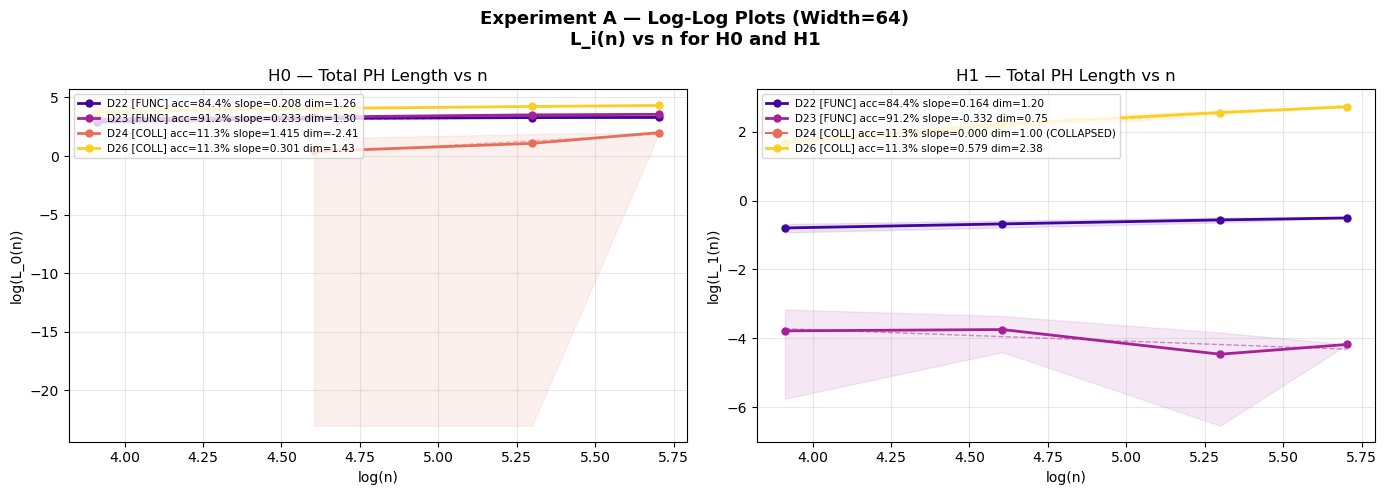

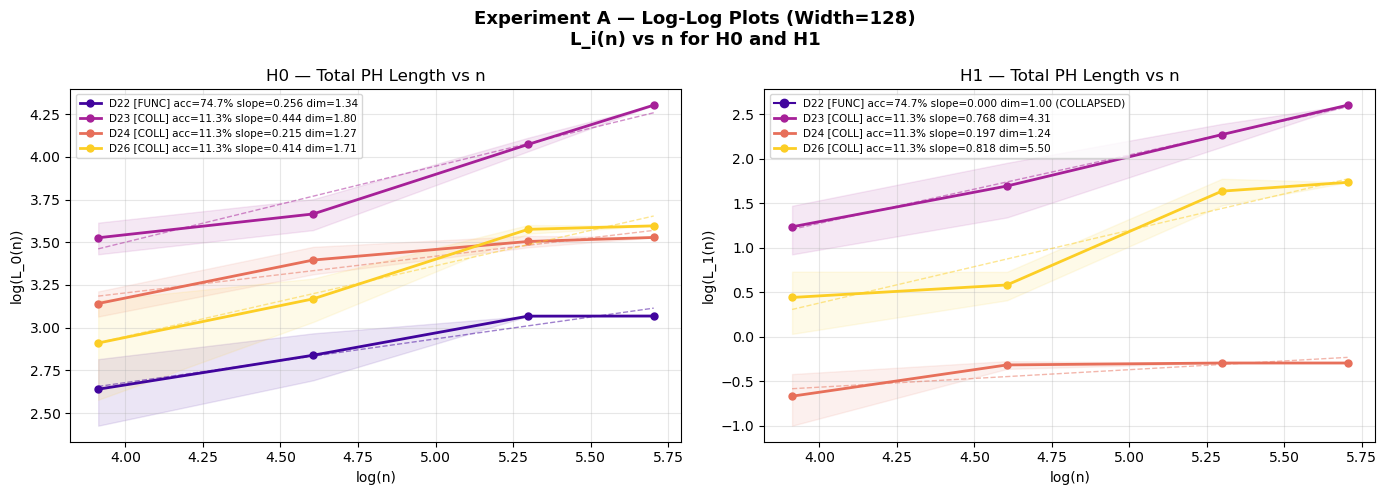

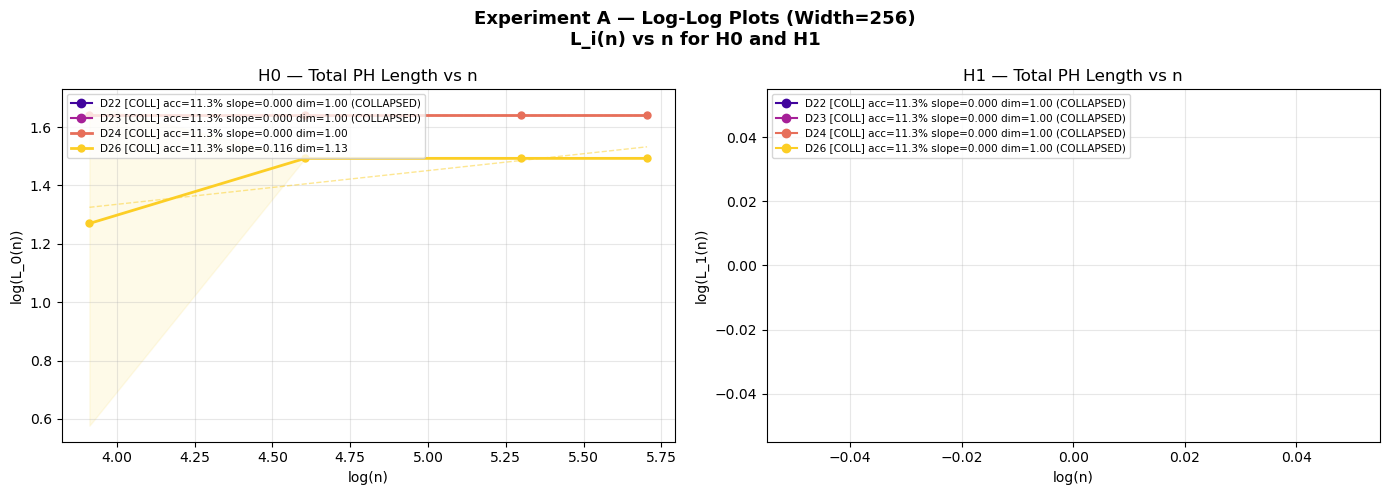

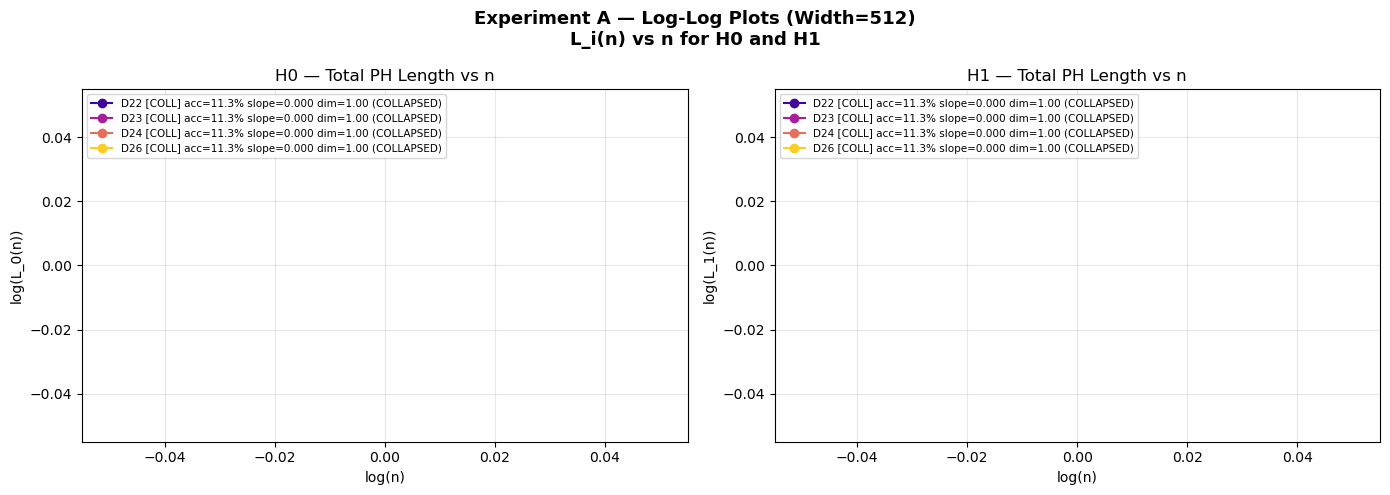

In [116]:
# ── 10. EXPERIMENT A PLOTS (NULL-SAFE VERSION) ──────────────────

print('Generating Experiment A plots...')

for width in WIDTHS_TO_TEST:
    subset = [r for r in expA_results if r['width'] == width]
    if not subset: continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Experiment A — Log-Log Plots (Width={width})\n'
                 f'L_i(n) vs n for H0 and H1', fontsize=13, fontweight='bold')
    colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(subset)))

    for ax_idx, dim_key in enumerate(['H0', 'H1']):
        ax = axes[ax_idx]
        ax.set_title(f'H{ax_idx} — Total PH Length vs n')
        ax.set_xlabel('log(n)')
        ax.set_ylabel(f'log(L_{ax_idx}(n))')

        for i, r in enumerate(sorted(subset, key=lambda x: x['depth'])):
            ph = r['ph_data']
            ns = np.array(ph['n_values'])
            lm = np.array(ph[f"L{ax_idx}_mean"])
            ls = np.array(ph[f"L{ax_idx}_std"])
            
            # --- NULL SAFETY HANDLING ---
            # Replace None/NaN with 0.0 for display purposes
            slope = ph.get(f'slope_{dim_key}') or 0.0
            dim   = ph.get(f'dim_PH_{dim_key}') or 0.0
            if np.isnan(slope): slope = 0.0
            if np.isnan(dim): dim = 0.0

            lbl = (f"D{r['depth']} [{r['status'][:4]}] "
                   f"acc={r['final_acc']:.1f}% "
                   f"slope={slope:.3f} dim={dim:.2f}")

            # If the model is collapsed (lm is all 0s), we skip the line 
            # but we still want it in the legend to show it failed.
            valid = lm > 1e-9 
            
            if valid.sum() < 2:
                # Add a "proxy" artist just for the legend so it's not empty
                ax.plot([], [], 'o-', color=colors[i], label=lbl + " (COLLAPSED)")
                continue

            # Plotting the actual data
            ax.plot(np.log(ns[valid]), np.log(lm[valid]),
                    'o-', color=colors[i], label=lbl, linewidth=2, markersize=5)
            
            # Error band
            ax.fill_between(
                np.log(ns[valid]),
                np.log(np.maximum(lm[valid] - ls[valid], 1e-10)),
                np.log(lm[valid] + ls[valid]),
                color=colors[i], alpha=0.1
            )
            
            # Fit line - only if slope exists
            log_n_range = np.array([np.log(ns[valid].min()), np.log(ns[valid].max())])
            intercept = np.log(lm[valid]).mean() - slope * np.log(ns[valid]).mean()
            ax.plot(log_n_range, slope * log_n_range + intercept,
                    '--', color=colors[i], alpha=0.5, linewidth=1)

        ax.legend(fontsize=7.5, loc='upper left')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

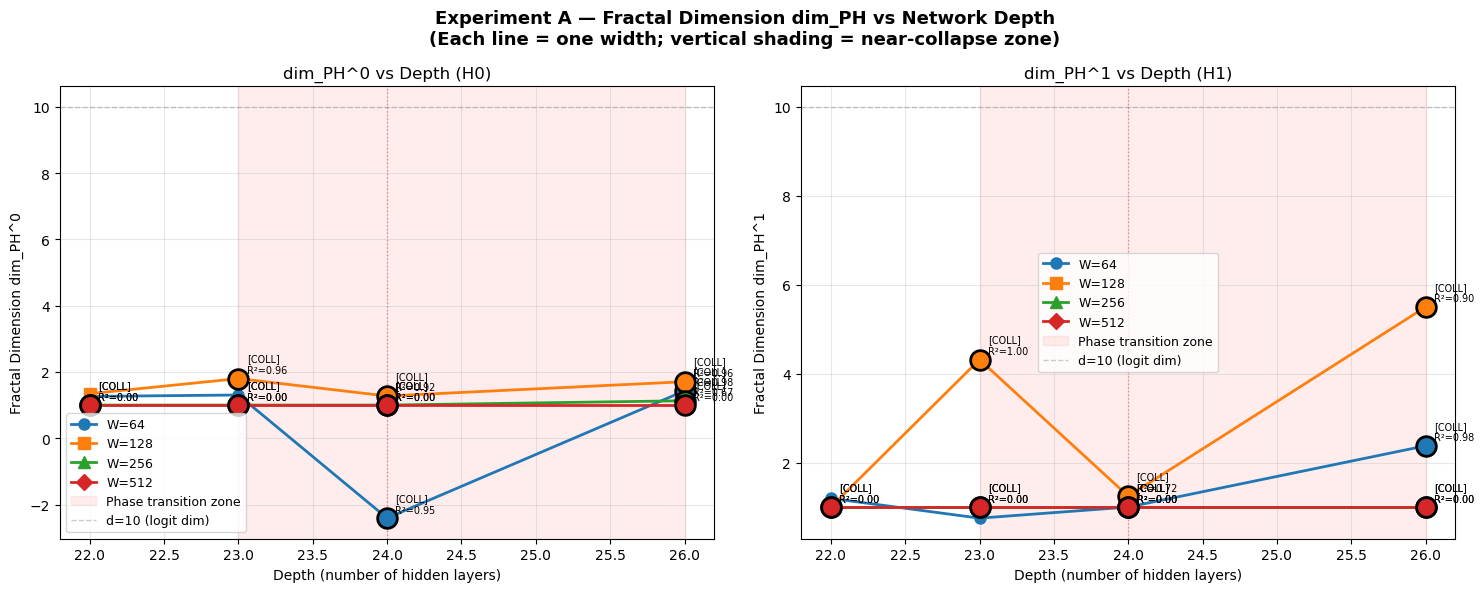

Saved: expA_dimPH_vs_depth.png


In [89]:
# ── 11. EXPERIMENT A: dim_PH vs DEPTH (phase transition signature plot) ───────

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Experiment A — Fractal Dimension dim_PH vs Network Depth\n'
             '(Each line = one width; vertical shading = near-collapse zone)',
             fontsize=13, fontweight='bold')

width_colors  = {64: '#1f77b4', 128: '#ff7f0e', 256: '#2ca02c', 512: '#d62728'}
width_markers = {64: 'o', 128: 's', 256: '^', 512: 'D'}

for ax_idx, dim_key in enumerate(['H0', 'H1']):
    ax = axes[ax_idx]
    ax.set_title(f'dim_PH^{ax_idx} vs Depth (H{ax_idx})', fontsize=12)
    ax.set_xlabel('Depth (number of hidden layers)')
    ax.set_ylabel(f'Fractal Dimension dim_PH^{ax_idx}')

    for width in WIDTHS_TO_TEST:
        subset  = sorted([r for r in expA_results if r['width'] == width], key=lambda x: x['depth'])
        depths  = [r['depth'] for r in subset]
        dims    = [r['ph_data'][f'dim_PH_{dim_key}'] for r in subset]
        r2s     = [r['ph_data'][f'r2_{dim_key}'] for r in subset]
        statuses = [r['status'] for r in subset]

        ax.plot(depths, dims, '-', color=width_colors[width],
                marker=width_markers[width], markersize=8, linewidth=2,
                label=f'W={width}')

        # Mark near-collapse / collapsed points
        for d, dim, st, r2 in zip(depths, dims, statuses, r2s):
            if st != 'FUNCTIONAL':
                ax.scatter([d], [dim], s=200, color=width_colors[width],
                           edgecolors='black', linewidths=2, zorder=5)
                ax.annotate(f'[{st[:4]}]\nR²={r2:.2f}',
                            (d, dim), textcoords='offset points',
                            xytext=(6, 4), fontsize=7)

    # Shade the near-collapse / phase transition zone
    # Based on Week 3 report: boundary around D23-D26 for various widths
    ax.axvspan(23, 26, alpha=0.07, color='red', label='Phase transition zone')
    ax.axvline(x=24, color='red', linestyle=':', alpha=0.4, linewidth=1)

    # Reference line: for a 10-class logit space, we might expect ~10D
    ax.axhline(y=10, color='gray', linestyle='--', alpha=0.4, linewidth=1, label='d=10 (logit dim)')

    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('expA_dimPH_vs_depth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: expA_dimPH_vs_depth.png')

In [90]:
# ── 12. EXPERIMENT A: SUMMARY TABLE ──────────────────────────────────────────

print('\n' + '='*80)
print('EXPERIMENT A — SUMMARY TABLE: Fractal Dimension of Logit Representations')
print('='*80)

rows = []
for r in sorted(expA_results, key=lambda x: (x['width'], x['depth'])):
    ph = r['ph_data']
    rows.append({
        'Depth'      : r['depth'],
        'Width'      : r['width'],
        'Status'     : r['status'],
        'Final Acc%' : round(r['final_acc'], 2),
        'Best Acc%'  : round(r['best_acc'],  2),
        'slope_H0'   : round(ph['slope_H0'],  4),
        'R2_H0'      : round(ph['r2_H0'],     4),
        'dim_PH_H0'  : round(ph['dim_PH_H0'], 3),
        'slope_H1'   : round(ph['slope_H1'],  4),
        'R2_H1'      : round(ph['r2_H1'],     4),
        'dim_PH_H1'  : round(ph['dim_PH_H1'], 3),
    })

df_A = pd.DataFrame(rows)

# Color-code by status for display
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print(df_A.to_string(index=False))

# Also save to CSV
df_A.to_csv('expA_results.csv', index=False)
print('\nSaved: expA_results.csv')


EXPERIMENT A — SUMMARY TABLE: Fractal Dimension of Logit Representations
 Depth  Width     Status  Final Acc%  Best Acc%  slope_H0  R2_H0  dim_PH_H0  slope_H1  R2_H1  dim_PH_H1
    22     64 FUNCTIONAL      84.430     90.610     0.208  0.823      1.262     0.164  0.999      1.196
    23     64 FUNCTIONAL      91.200     91.200     0.233  0.986      1.304    -0.332  0.589      0.751
    24     64  COLLAPSED      11.350     11.350     1.415  0.948     -2.410     0.000  0.000      1.000
    26     64  COLLAPSED      11.350     11.350     0.301  0.976      1.430     0.579  0.980      2.377
    22    128 FUNCTIONAL      74.680     84.500     0.256  0.956      1.343     0.000  0.000      1.000
    23    128  COLLAPSED      11.350     11.350     0.444  0.956      1.800     0.768  0.997      4.314
    24    128  COLLAPSED      11.350     11.350     0.215  0.915      1.273     0.197  0.717      1.245
    26    128  COLLAPSED      11.350     11.350     0.414  0.963      1.706     0.818  0.897  

Generating Experiment B plots...


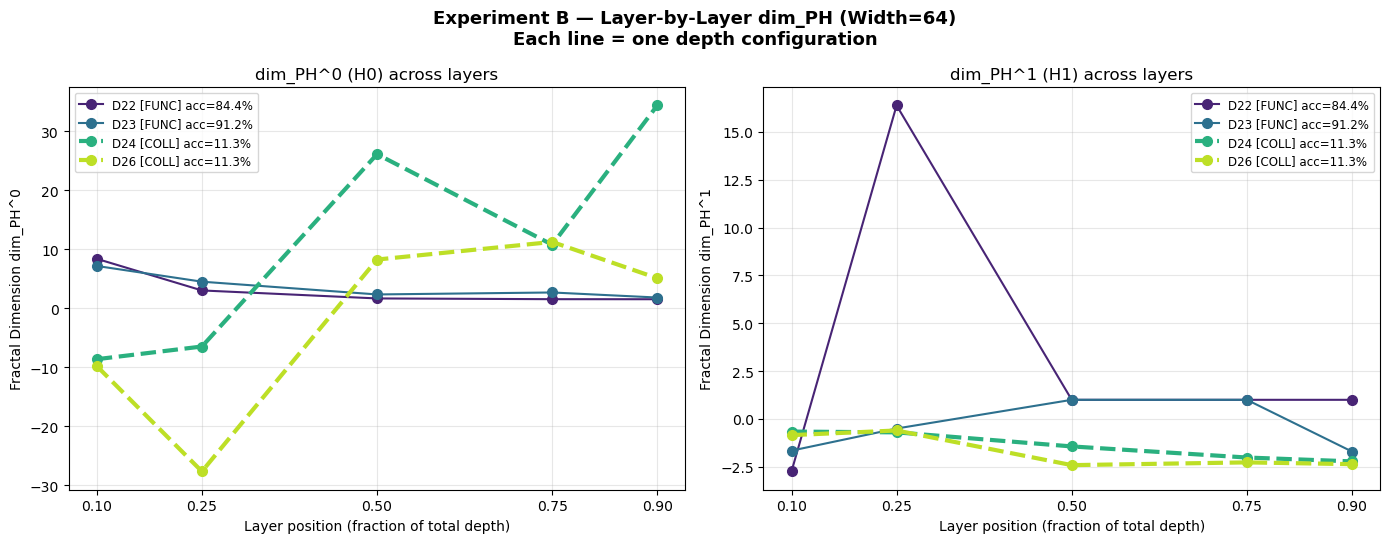

  Saved: expB_layer_dimPH_W64.png


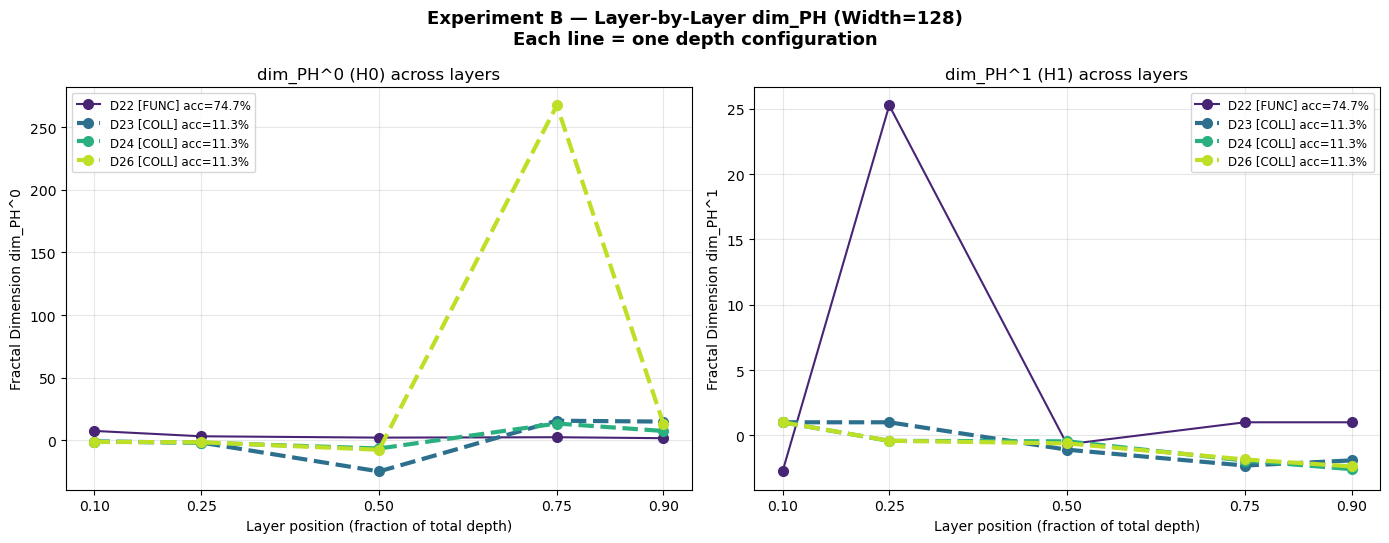

  Saved: expB_layer_dimPH_W128.png


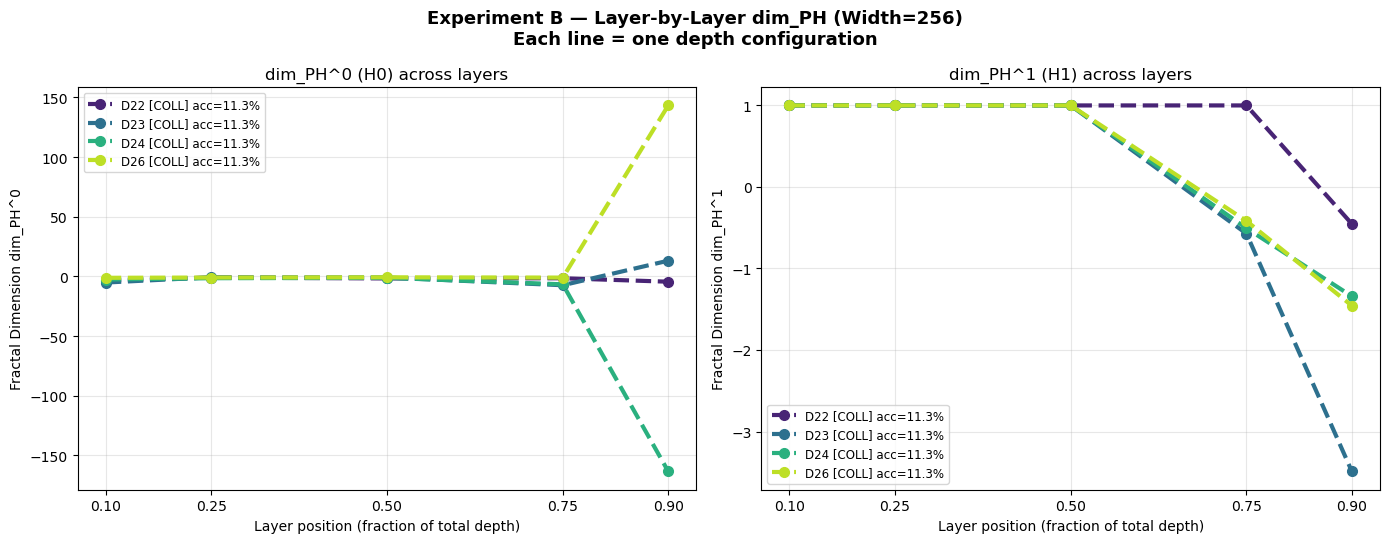

  Saved: expB_layer_dimPH_W256.png


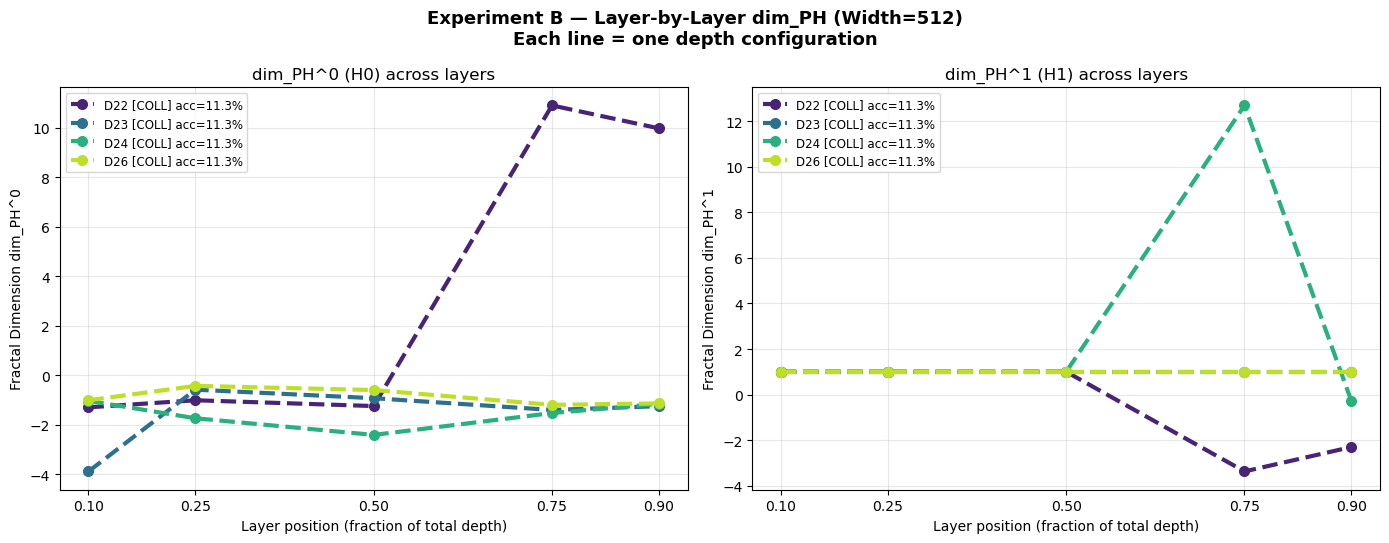

  Saved: expB_layer_dimPH_W512.png
Experiment B plots done.


In [91]:
# ── 13. EXPERIMENT B PLOTS: LAYER-BY-LAYER dim_PH ────────────────────────────

print('Generating Experiment B plots...')

# For each width, plot dim_PH vs layer_fraction for all depths (all on one figure)
for width in WIDTHS_TO_TEST:
    subset = [r for r in expB_results if r['width'] == width]
    depths_present = sorted(set(r['depth'] for r in subset))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    fig.suptitle(f'Experiment B — Layer-by-Layer dim_PH (Width={width})\n'
                 f'Each line = one depth configuration',
                 fontsize=13, fontweight='bold')

    depth_colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(depths_present)))

    for ax_idx, dim_key in enumerate(['H0', 'H1']):
        ax = axes[ax_idx]
        ax.set_title(f'dim_PH^{ax_idx} (H{ax_idx}) across layers')
        ax.set_xlabel('Layer position (fraction of total depth)')
        ax.set_ylabel(f'Fractal Dimension dim_PH^{ax_idx}')

        for di, depth in enumerate(depths_present):
            depth_subset = sorted([r for r in subset if r['depth'] == depth],
                                   key=lambda x: x['layer_frac'])
            if not depth_subset:
                continue
            fracs = [r['layer_frac'] for r in depth_subset]
            dims  = [r['ph_data'][f'dim_PH_{dim_key}'] for r in depth_subset]
            st    = depth_subset[0]['status']
            acc   = depth_subset[0]['final_acc']
            lbl   = f'D{depth} [{st[:4]}] acc={acc:.1f}%'

            lw = 3 if st != 'FUNCTIONAL' else 1.5
            ls = '--' if st != 'FUNCTIONAL' else '-'
            ax.plot(fracs, dims, ls, color=depth_colors[di], marker='o',
                    markersize=7, linewidth=lw, label=lbl)

        ax.legend(fontsize=8.5)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(LAYER_FRACTIONS)
        ax.set_xticklabels([f'{f:.2f}' for f in LAYER_FRACTIONS])

    plt.tight_layout()
    plt.savefig(f'expB_layer_dimPH_W{width}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: expB_layer_dimPH_W{width}.png')

print('Experiment B plots done.')

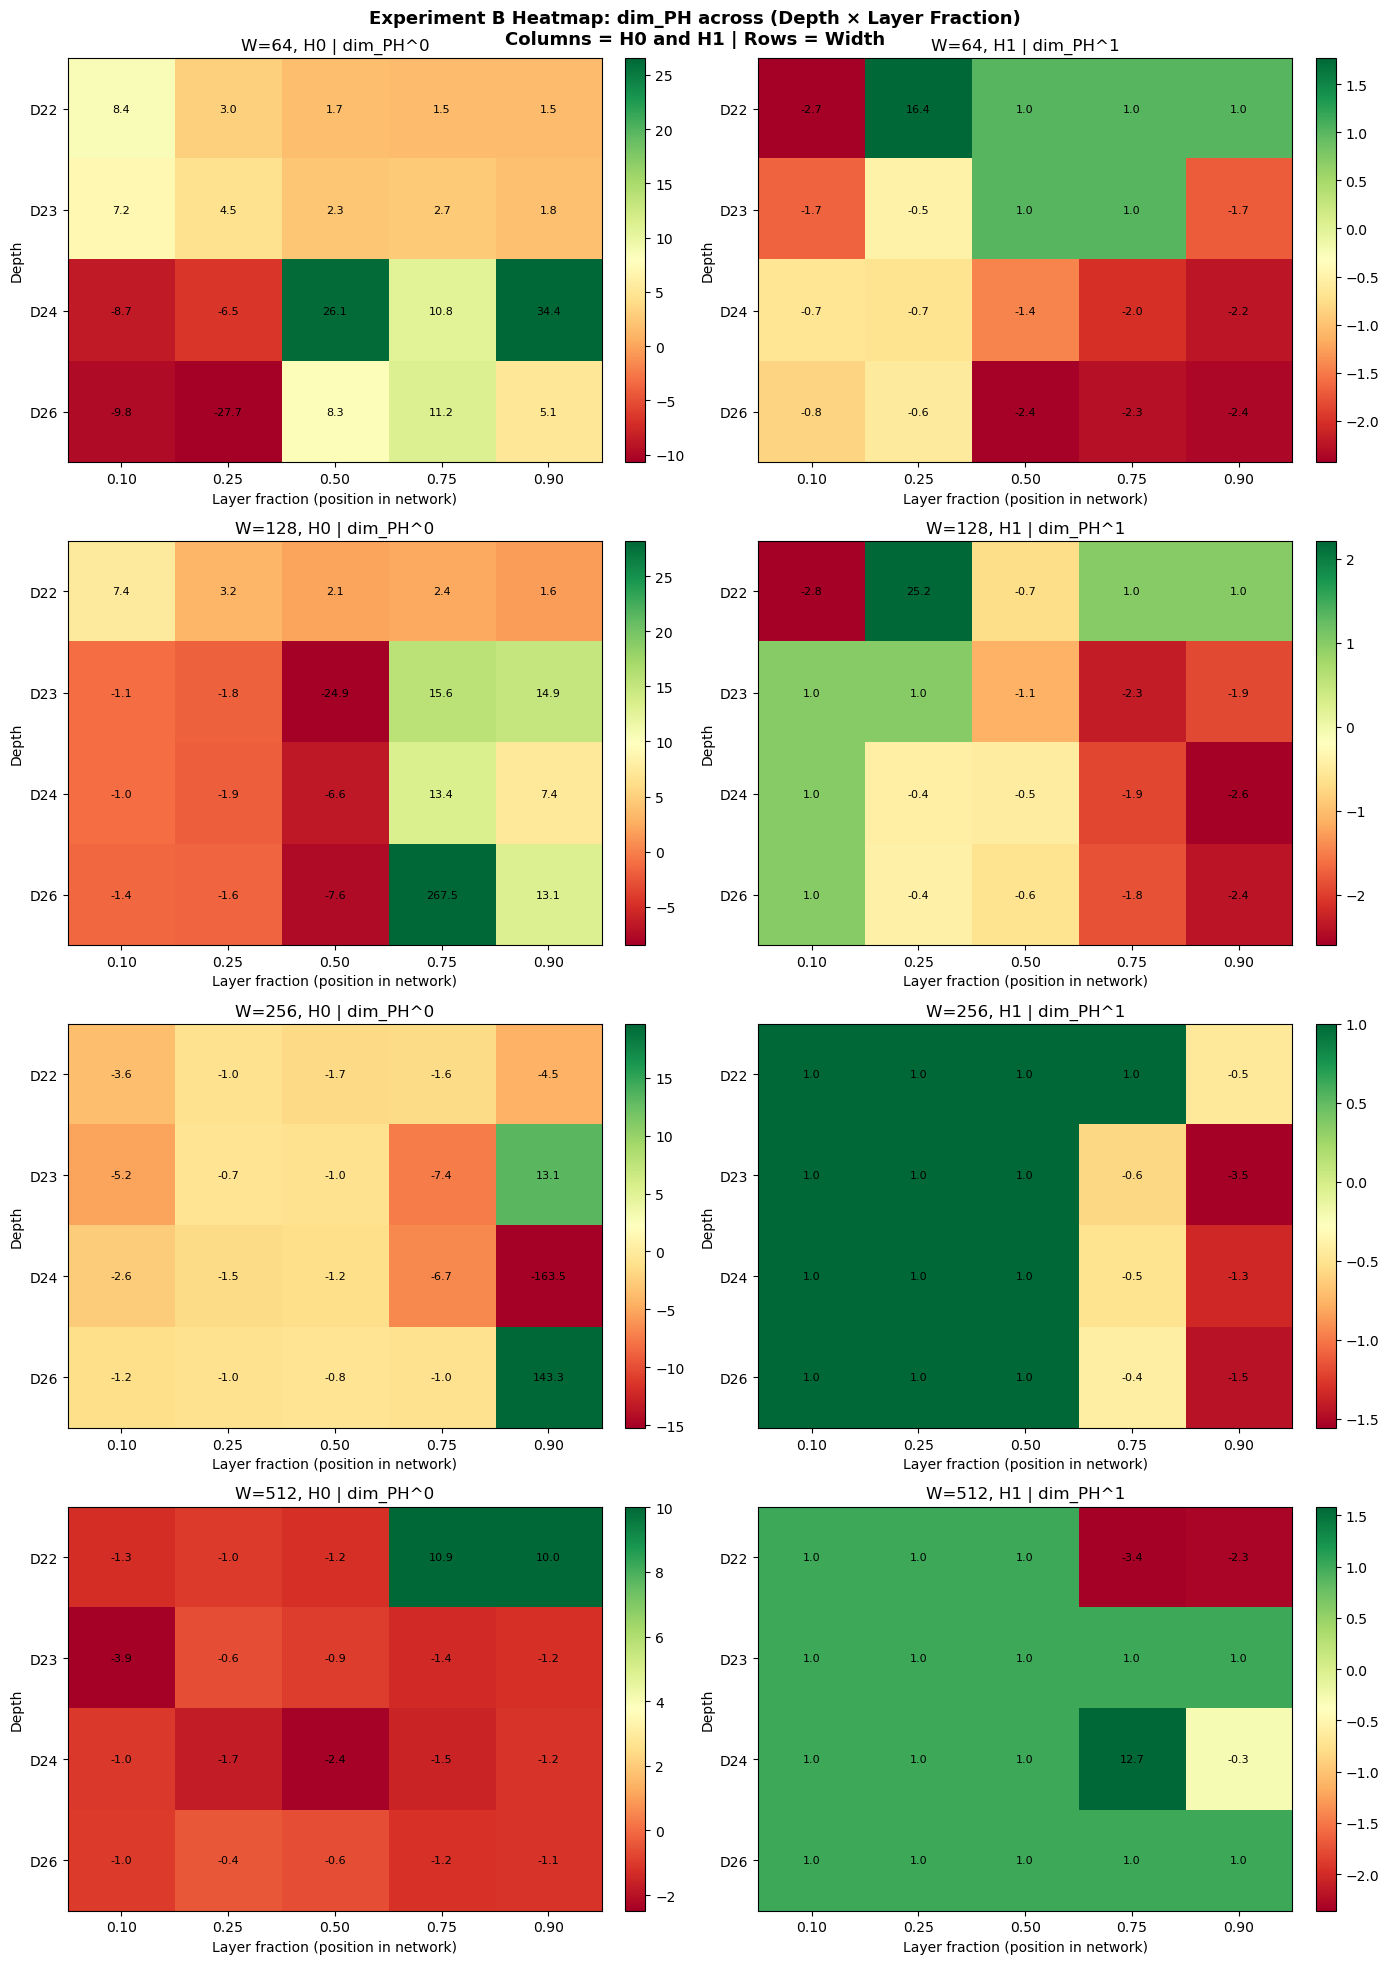

Saved: expB_heatmap_dimPH.png


In [92]:
# ── 14. EXPERIMENT B: HEATMAP — dim_PH_H0 across (Depth × Layer position) ────

fig, axes = plt.subplots(len(WIDTHS_TO_TEST), 2, figsize=(14, 5 * len(WIDTHS_TO_TEST)))
fig.suptitle('Experiment B Heatmap: dim_PH across (Depth × Layer Fraction)\n'
             'Columns = H0 and H1 | Rows = Width',
             fontsize=13, fontweight='bold')

for wi, width in enumerate(WIDTHS_TO_TEST):
    for di_key, dim_key in enumerate(['H0', 'H1']):
        ax = axes[wi][di_key]
        # Build matrix: rows = depths, cols = layer fractions
        depths_sorted = sorted(DEPTHS_TO_TEST)
        fracs_sorted  = sorted(LAYER_FRACTIONS)
        matrix = np.full((len(depths_sorted), len(fracs_sorted)), np.nan)

        for ri, depth in enumerate(depths_sorted):
            for fi, frac in enumerate(fracs_sorted):
                match = [r for r in expB_results
                         if r['depth'] == depth and r['width'] == width
                         and abs(r['layer_frac'] - frac) < 0.01]
                if match:
                    matrix[ri, fi] = match[0]['ph_data'][f'dim_PH_{dim_key}']

        # Clamp extreme values for visualization
        matrix_plot = np.where(np.isfinite(matrix), matrix, np.nan)
        vmin = np.nanpercentile(matrix_plot, 5)  if not np.all(np.isnan(matrix_plot)) else 0
        vmax = np.nanpercentile(matrix_plot, 95) if not np.all(np.isnan(matrix_plot)) else 1

        im = ax.imshow(matrix_plot, aspect='auto', cmap='RdYlGn',
                       vmin=vmin, vmax=vmax)
        ax.set_xticks(range(len(fracs_sorted)))
        ax.set_xticklabels([f'{f:.2f}' for f in fracs_sorted])
        ax.set_yticks(range(len(depths_sorted)))
        ax.set_yticklabels([f'D{d}' for d in depths_sorted])
        ax.set_xlabel('Layer fraction (position in network)')
        ax.set_ylabel('Depth')
        ax.set_title(f'W={width}, {dim_key} | dim_PH^{di_key}')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # Add value annotations
        for ri in range(len(depths_sorted)):
            for fi in range(len(fracs_sorted)):
                val = matrix[ri, fi]
                if np.isfinite(val):
                    ax.text(fi, ri, f'{val:.1f}', ha='center', va='center',
                            fontsize=8, color='black')

plt.tight_layout()
plt.savefig('expB_heatmap_dimPH.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: expB_heatmap_dimPH.png')

In [93]:
# ── 15. EXPERIMENT B: SUMMARY TABLE ──────────────────────────────────────────

print('\n' + '='*100)
print('EXPERIMENT B — SUMMARY TABLE: Layer-by-Layer Fractal Dimension')
print('='*100)

rows_B = []
for r in sorted(expB_results, key=lambda x: (x['width'], x['depth'], x['layer_frac'])):
    ph = r['ph_data']
    rows_B.append({
        'Depth'     : r['depth'],
        'Width'     : r['width'],
        'Status'    : r['status'],
        'Acc%'      : round(r['final_acc'], 2),
        'LayerFrac' : round(r['layer_frac'], 2),
        'LayerNum'  : r['layer_num'],
        'slope_H0'  : round(ph['slope_H0'],   4),
        'R2_H0'     : round(ph['r2_H0'],      4),
        'dim_PH_H0' : round(ph['dim_PH_H0'],  3),
        'slope_H1'  : round(ph['slope_H1'],   4),
        'R2_H1'     : round(ph['r2_H1'],      4),
        'dim_PH_H1' : round(ph['dim_PH_H1'],  3),
    })

df_B = pd.DataFrame(rows_B)
print(df_B.to_string(index=False))
df_B.to_csv('expB_results.csv', index=False)
print('\nSaved: expB_results.csv')


EXPERIMENT B — SUMMARY TABLE: Layer-by-Layer Fractal Dimension
 Depth  Width     Status   Acc%  LayerFrac  LayerNum  slope_H0  R2_H0  dim_PH_H0  slope_H1  R2_H1  dim_PH_H1
    22     64 FUNCTIONAL 84.430      0.100         2     0.881  1.000      8.378     1.365  0.986     -2.743
    22     64 FUNCTIONAL 84.430      0.250         5     0.668  1.000      3.013     0.939  0.986     16.386
    22     64 FUNCTIONAL 84.430      0.500        10     0.396  0.837      1.656     0.000  0.000      1.000
    22     64 FUNCTIONAL 84.430      0.750        15     0.346  0.888      1.530     0.000  0.000      1.000
    22     64 FUNCTIONAL 84.430      0.900        18     0.343  0.951      1.521     0.000  0.000      1.000
    23     64 FUNCTIONAL 91.200      0.100         2     0.861  0.999      7.166     1.603  0.999     -1.657
    23     64 FUNCTIONAL 91.200      0.250         5     0.778  0.973      4.499     3.000  0.943     -0.500
    23     64 FUNCTIONAL 91.200      0.500        11     0.572  

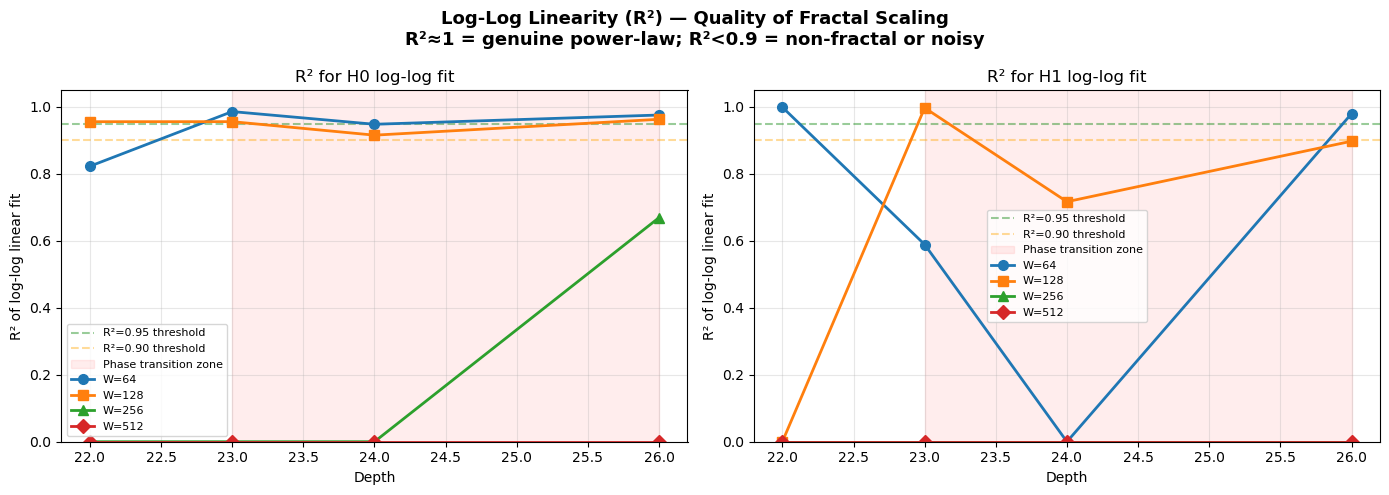

Saved: expA_r2_linearity.png


In [94]:
# ── 16. LINEARITY CHECK: R² distribution plot ─────────────────────────────────
# An R² near 1 means the log-log plot is truly linear = genuine power-law fractal scaling
# Near the phase transition, R² may drop (indicating breakdown of pure fractal structure)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Log-Log Linearity (R²) — Quality of Fractal Scaling\n'
             'R²≈1 = genuine power-law; R²<0.9 = non-fractal or noisy',
             fontsize=13, fontweight='bold')

for ax_idx, dim_key in enumerate(['H0', 'H1']):
    ax = axes[ax_idx]
    ax.set_title(f'R² for {dim_key} log-log fit')
    ax.set_xlabel('Depth')
    ax.set_ylabel('R² of log-log linear fit')
    ax.axhline(y=0.95, color='green', linestyle='--', alpha=0.4, label='R²=0.95 threshold')
    ax.axhline(y=0.90, color='orange', linestyle='--', alpha=0.4, label='R²=0.90 threshold')
    ax.axvspan(23, 26, alpha=0.07, color='red', label='Phase transition zone')

    for width in WIDTHS_TO_TEST:
        subset = sorted([r for r in expA_results if r['width'] == width], key=lambda x: x['depth'])
        depths = [r['depth'] for r in subset]
        r2s    = [r['ph_data'][f'r2_{dim_key}'] for r in subset]
        ax.plot(depths, r2s, '-o', label=f'W={width}', linewidth=2, markersize=7,
                color=width_colors[width], marker=width_markers[width])

    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('expA_r2_linearity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: expA_r2_linearity.png')

In [95]:
# ── 17. COMPILE ALL RESULTS FOR MENTOR DISCUSSION ────────────────────────────

print('\n' + '█'*80)
print('COMPILED RESULTS SUMMARY — READY FOR MENTOR DISCUSSION')
print('█'*80)

# ─ A. Phase diagram summary
print('\n[1] PHASE DIAGRAM — TRAINING OUTCOMES')
print('-'*60)
phase_rows = []
for r in sorted(expA_results, key=lambda x: (x['depth'], x['width'])):
    phase_rows.append({'Depth': r['depth'], 'Width': r['width'],
                       'Final Acc%': round(r['final_acc'],2),
                       'Best Acc%': round(r['best_acc'],2),
                       'Status': r['status']})
df_phase = pd.DataFrame(phase_rows)
print(df_phase.to_string(index=False))

# ─ B. Key fractal dimension findings
print('\n[2] EXPERIMENT A — FRACTAL DIMENSIONS OF LOGIT REPRESENTATIONS')
print('Method: Adams et al. (1808.01079) log-log plot, L_i(n) ~ n^(1-1/dim_PH)')
print('-'*80)
print(df_A[['Depth','Width','Status','Final Acc%','slope_H0','R2_H0','dim_PH_H0','slope_H1','R2_H1','dim_PH_H1']].to_string(index=False))

# ─ C. Key fractal findings: is there an anomaly near phase transition?
print('\n[3] PHASE TRANSITION FRACTAL SIGNATURE — KEY OBSERVATIONS')
print('-'*70)
# For each width, print the dim_PH_H0 sequence across depths
for width in WIDTHS_TO_TEST:
    subset = sorted([r for r in expA_results if r['width']==width], key=lambda x: x['depth'])
    dims_H0 = [r['ph_data']['dim_PH_H0'] for r in subset]
    dims_H1 = [r['ph_data']['dim_PH_H1'] for r in subset]
    r2s_H0  = [r['ph_data']['r2_H0']     for r in subset]
    depths  = [r['depth'] for r in subset]
    statuses = [r['status'] for r in subset]
    print(f'  W={width}:')
    for d, dh0, dh1, r2, st in zip(depths, dims_H0, dims_H1, r2s_H0, statuses):
        flag = ' ← COLLAPSE' if st != 'FUNCTIONAL' else ''
        print(f'    D{d:2d} [{st:14s}]: dim_H0={dh0:6.2f}  dim_H1={dh1:6.2f}  R2_H0={r2:.3f}{flag}')

# ─ D. Experiment B: layer-by-layer trends
print('\n[4] EXPERIMENT B — LAYER-BY-LAYER dim_PH TRENDS')
print('-'*70)
for width in WIDTHS_TO_TEST:
    print(f'  Width={width}:')
    for depth in DEPTHS_TO_TEST:
        status = next(r['status'] for r in expA_results if r['depth']==depth and r['width']==width)
        subset = sorted([r for r in expB_results if r['depth']==depth and r['width']==width],
                        key=lambda x: x['layer_frac'])
        dims   = [f"{r['ph_data']['dim_PH_H0']:5.2f}" for r in subset]
        fracs  = [f"{r['layer_frac']:.2f}" for r in subset]
        print(f'    D{depth:2d} [{status:14s}]: fracs={fracs} → dim_H0={dims}')

# ─ E. Fractality assessment
print('\n[5] FRACTALITY ASSESSMENT (R² of log-log fit)')
print('R²>0.95 → genuine power-law (fractal) scaling')
print('R²<0.90 → breakdown of pure fractal structure')
print('-'*70)
for r in sorted(expA_results, key=lambda x: (x['width'], x['depth'])):
    ph  = r['ph_data']
    h0_fractal = 'FRACTAL' if ph['r2_H0'] > 0.95 else ('WEAK' if ph['r2_H0'] > 0.90 else 'NON-FRACTAL')
    h1_fractal = 'FRACTAL' if ph['r2_H1'] > 0.95 else ('WEAK' if ph['r2_H1'] > 0.90 else 'NON-FRACTAL')
    print(f'  D{r["depth"]:2d} W{r["width"]:3d} [{r["status"]:14s}]: '
          f'H0→{h0_fractal:11s}(R²={ph["r2_H0"]:.3f})  H1→{h1_fractal:11s}(R²={ph["r2_H1"]:.3f})')

print('\n' + '█'*80)
print('All plots saved. Tables saved to CSV. Ready for analysis.')
print('█'*80)


████████████████████████████████████████████████████████████████████████████████
COMPILED RESULTS SUMMARY — READY FOR MENTOR DISCUSSION
████████████████████████████████████████████████████████████████████████████████

[1] PHASE DIAGRAM — TRAINING OUTCOMES
------------------------------------------------------------
 Depth  Width  Final Acc%  Best Acc%     Status
    22     64      84.430     90.610 FUNCTIONAL
    22    128      74.680     84.500 FUNCTIONAL
    22    256      11.350     11.350  COLLAPSED
    22    512      11.350     11.350  COLLAPSED
    23     64      91.200     91.200 FUNCTIONAL
    23    128      11.350     11.350  COLLAPSED
    23    256      11.350     11.350  COLLAPSED
    23    512      11.350     11.350  COLLAPSED
    24     64      11.350     11.350  COLLAPSED
    24    128      11.350     11.350  COLLAPSED
    24    256      11.350     11.350  COLLAPSED
    24    512      11.350     11.350  COLLAPSED
    26     64      11.350     11.350  COLLAPSED
    26    

In [96]:
# ── 18. SAVE FULL RESULTS TO JSON (for feeding back to Claude for analysis) ───

def make_serializable(obj):
    if isinstance(obj, dict):
        return {k: make_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [make_serializable(v) for v in obj]
    elif isinstance(obj, float):
        return None if (np.isnan(obj) or np.isinf(obj)) else round(obj, 6)
    elif isinstance(obj, np.floating):
        return None if (np.isnan(obj) or np.isinf(obj)) else round(float(obj), 6)
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj

# Strip the heavy ph_data raw arrays for the summary export, keep derived stats
def strip_ph_data(r):
    ph = r['ph_data']
    return {
        k: v for k, v in r.items() if k != 'ph_data'
    } | {
        'slope_H0'   : ph['slope_H0'],
        'r2_H0'      : ph['r2_H0'],
        'dim_PH_H0'  : ph['dim_PH_H0'],
        'slope_H1'   : ph['slope_H1'],
        'r2_H1'      : ph['r2_H1'],
        'dim_PH_H1'  : ph['dim_PH_H1'],
        'n_values'   : ph['n_values'],
        'L0_mean'    : ph['L0_mean'],
        'L1_mean'    : ph['L1_mean'],
    }

summary = {
    'config': {
        'DEPTHS'       : DEPTHS_TO_TEST,
        'WIDTHS'       : WIDTHS_TO_TEST,
        'EPOCHS'       : EPOCHS,
        'N_VALUES'     : N_VALUES,
        'N_REPEATS'    : N_REPEATS,
        'PCA_DIM'      : PCA_DIM,
        'LAYER_FRACTIONS': LAYER_FRACTIONS,
    },
    'experiment_A': [make_serializable(strip_ph_data(r)) for r in expA_results],
    'experiment_B': [make_serializable(strip_ph_data(r)) for r in expB_results],
}

with open('week4_fractal_results.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('All results saved to week4_fractal_results.json')
print('\nFiles generated this session:')
import glob
for fn in sorted(glob.glob('*.png') + glob.glob('*.csv') + glob.glob('*.json')):
    size = os.path.getsize(fn)
    print(f'  {fn:45s}  {size/1024:.1f} KB')

print('\n✓ Notebook complete. Paste week4_fractal_results.json back to Claude for analysis.')

All results saved to week4_fractal_results.json

Files generated this session:
  expA_dimPH_vs_depth.png                        169.3 KB
  expA_loglog_W128.png                           204.9 KB
  expA_loglog_W256.png                           85.4 KB
  expA_loglog_W512.png                           51.6 KB
  expA_loglog_W64.png                            135.3 KB
  expA_r2_linearity.png                          138.7 KB
  expA_results.csv                               1.0 KB
  expB_heatmap_dimPH.png                         247.4 KB
  expB_layer_dimPH_W128.png                      135.3 KB
  expB_layer_dimPH_W256.png                      130.8 KB
  expB_layer_dimPH_W512.png                      124.6 KB
  expB_layer_dimPH_W64.png                       149.4 KB
  expB_results.csv                               5.3 KB
  week4_fractal_results.json                     57.3 KB

✓ Notebook complete. Paste week4_fractal_results.json back to Claude for analysis.
